Preparing Ground Truth Object...
Simulating capture of LR images with 150.0 um defocus...
Running Uncorrected Reconstruction (Naive approach)...
Running Corrected Reconstruction (Digital Wavefront Correction)...
Plotting Results...


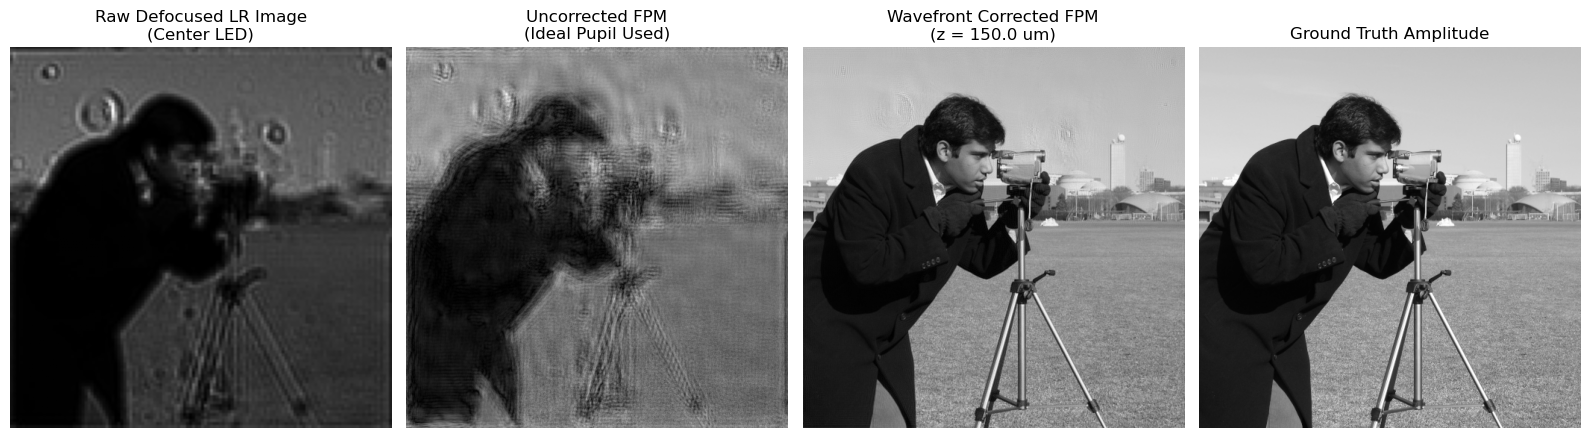

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform

def simulate_fpm_wavefront_correction():
    """
    Simulates FPM with a defocused sample and implements digital wavefront correction 
    to iteratively recover the in-focus high-resolution complex field.
    """
    # ==========================================
    # 1. System Parameters & Setup
    # ==========================================
    wavelength = 0.532e-3  # Wavelength in mm (532 nm Green LED)
    k0 = 2 * np.pi / wavelength
    
    NA_obj = 0.08           # Objective Numerical Aperture
    mag = 2.0              # Magnification
    
    # LED Array Parameters
    led_grid_size = 7      # 7x7 LED array
    led_spacing = 4.0      # 4mm spacing between LEDs
    z_led = 60.0           # Distance from LED array to sample in mm
    
    # Defocus Parameter
    z_defocus = 0.150      # Sample is defocused by 150 um (0.15 mm)
    
    # Camera / Resolution Parameters
    cam_pixel_size = 6.5e-3 
    dx_lr = cam_pixel_size / mag  # Effective pixel size at the object plane
    
    upsample_factor = 4
    N_lr = 128              # LR image size
    N_hr = N_lr * upsample_factor # HR image size (256x256)
    dx_hr = dx_lr / upsample_factor
    
    # ==========================================
    # 2. Create the "Ground Truth" Complex Object
    # ==========================================
    print("Preparing Ground Truth Object...")
    amp = transform.resize(data.camera(), (N_hr, N_hr), anti_aliasing=True)
    phase = transform.resize(data.moon(), (N_hr, N_hr), anti_aliasing=True)
    
    amp = amp / np.max(amp)
    phase = (phase / np.max(phase)) * np.pi
    obj_hr_gt = amp * np.exp(1j * phase)
    O_hr_gt = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(obj_hr_gt)))
    
    # ==========================================
    # 3. Define Spatial Frequencies and Pupils
    # ==========================================
    # HR and LR spatial frequency coordinates (cycles/mm)
    fx_hr = np.fft.fftshift(np.fft.fftfreq(N_hr, d=dx_hr))
    fy_hr = np.fft.fftshift(np.fft.fftfreq(N_hr, d=dx_hr))
    
    fx_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=dx_lr))
    fy_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=dx_lr))
    FX_lr, FY_lr = np.meshgrid(fx_lr, fy_lr)
    
    # Ideal Pupil (Low-pass filter)
    cutoff_freq = NA_obj / wavelength
    pupil_radius = np.sqrt(FX_lr**2 + FY_lr**2)
    pupil_ideal = (pupil_radius <= cutoff_freq).astype(float)
    
    # Aberrated Pupil (includes defocus phase factor)
    # The phase factor is e^(i * z * k_z) where k_z = 2*pi*sqrt((1/lambda)^2 - fx^2 - fy^2)
    radicand = np.maximum((1/wavelength)**2 - FX_lr**2 - FY_lr**2, 0)
    kz = 2 * np.pi * np.sqrt(radicand)
    defocus_phase = z_defocus * kz
    
    # The generalized pupil function includes the physical aberration
    pupil_aberrated = pupil_ideal * np.exp(1j * defocus_phase)
    
    # ==========================================
    # 4. Forward Model: Generate Defocused LR Images
    # ==========================================
    print(f"Simulating capture of LR images with {z_defocus*1000} um defocus...")
    
    led_idx = np.arange(-led_grid_size//2 + 1, led_grid_size//2 + 1)
    x_led, y_led = np.meshgrid(led_idx * led_spacing, led_idx * led_spacing)
    
    # Direction cosines for oblique illumination
    kx_led = (x_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)) / wavelength
    ky_led = (y_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)) / wavelength
    
    I_measured = np.zeros((led_grid_size, led_grid_size, N_lr, N_lr))
    
    for i in range(led_grid_size):
        for j in range(led_grid_size):
            shift_x = int(np.round(kx_led[i, j] * N_hr * dx_hr))
            shift_y = int(np.round(ky_led[i, j] * N_hr * dx_hr))
            
            center_y, center_x = N_hr//2 + shift_y, N_hr//2 + shift_x
            y_start, y_end = center_y - N_lr//2, center_y + N_lr//2
            x_start, x_end = center_x - N_lr//2, center_x + N_lr//2
            
            if (y_start >= 0 and y_end <= N_hr and x_start >= 0 and x_end <= N_hr):
                O_sub = O_hr_gt[y_start:y_end, x_start:x_end]
            else:
                O_sub = np.zeros((N_lr, N_lr), dtype=np.complex128)
            
            # Forward simulation strictly uses the aberrated pupil
            E_lr_fourier = O_sub * pupil_aberrated
            E_lr_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_lr_fourier)))
            I_measured[i, j] = np.abs(E_lr_spatial)**2

    # ==========================================
    # 5. Inverse Model Functions
    # ==========================================
    def reconstruct_fpm(pupil_model, iterations=30, alpha=1.0):
        """Standard alternating projections FPM solver using a provided pupil model."""
        O_recon = np.zeros((N_hr, N_hr), dtype=np.complex128)
        center_idx = led_grid_size // 2
        
        # Initialize with upsampled central image
        initial_amp = np.sqrt(I_measured[center_idx, center_idx])
        E_init_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(initial_amp)))
        O_recon[N_hr//2 - N_lr//2 : N_hr//2 + N_lr//2, 
                N_hr//2 - N_lr//2 : N_hr//2 + N_lr//2] = E_init_fourier
        
        # Precompute pupil intensity for gradient update
        pupil_intensity = np.abs(pupil_model)**2
        max_pupil = np.max(pupil_intensity)
        
        for it in range(iterations):
            for i in range(led_grid_size):
                for j in range(led_grid_size):
                    shift_x = int(np.round(kx_led[i, j] * N_hr * dx_hr))
                    shift_y = int(np.round(ky_led[i, j] * N_hr * dx_hr))
                    
                    center_y, center_x = N_hr//2 + shift_y, N_hr//2 + shift_x
                    y_start, y_end = center_y - N_lr//2, center_y + N_lr//2
                    x_start, x_end = center_x - N_lr//2, center_x + N_lr//2
                    
                    if (y_start < 0 or y_end > N_hr or x_start < 0 or x_end > N_hr):
                        continue
                    
                    O_sub = O_recon[y_start:y_end, x_start:x_end]
                    
                    # Step 2: Multiply by pupil function (includes phase factor if corrected)
                    E_est_fourier = O_sub * pupil_model
                    E_est_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_est_fourier)))
                    
                    # Apply amplitude constraint
                    amp_measured = np.sqrt(I_measured[i, j])
                    E_updated_spatial = amp_measured * np.exp(1j * np.angle(E_est_spatial))
                    E_updated_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(E_updated_spatial)))
                    
                    # Step 5: Update HR spectrum
                    # Multiplying by np.conj(pupil_model) inherently applies the inverse phase 
                    # factor e^{-i * phi} required for wavefront correction
                    update = (np.conj(pupil_model) / max_pupil) * (E_updated_fourier - E_est_fourier)
                    O_recon[y_start:y_end, x_start:x_end] += alpha * update

        obj_recon_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(O_recon)))
        return np.abs(obj_recon_spatial), np.angle(obj_recon_spatial)

    # ==========================================
    # 6. Run Reconstructions
    # ==========================================
    print("Running Uncorrected Reconstruction (Naive approach)...")
    amp_uncorrected, _ = reconstruct_fpm(pupil_ideal, iterations=20)
    
    print("Running Corrected Reconstruction (Digital Wavefront Correction)...")
    amp_corrected, phase_corrected = reconstruct_fpm(pupil_aberrated, iterations=20)

    # ==========================================
    # 7. Visualization
    # ==========================================
    print("Plotting Results...")
    plt.figure(figsize=(16, 8))
    
    center_idx = led_grid_size // 2
    
    plt.subplot(1, 4, 1)
    plt.title(f"Raw Defocused LR Image\n(Center LED)")
    plt.imshow(I_measured[center_idx, center_idx], cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 4, 2)
    plt.title("Uncorrected FPM\n(Ideal Pupil Used)")
    plt.imshow(amp_uncorrected, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 4, 3)
    plt.title(f"Wavefront Corrected FPM\n(z = {z_defocus*1000} um)")
    plt.imshow(amp_corrected, cmap='gray')
    plt.axis('off')
    
    plt.subplot(1, 4, 4)
    plt.title("Ground Truth Amplitude")
    plt.imshow(amp, cmap='gray')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    simulate_fpm_wavefront_correction()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as patches
from IPython.display import HTML
import warnings

# Suppress warnings for clean notebook output
warnings.filterwarnings('ignore') 

# --- Simulation Parameters ---
N = 256  # Grid size
grid_size = np.linspace(-1, 1, N)
X, Y = np.meshgrid(grid_size, grid_size)
R2 = X**2 + Y**2
aperture = R2 <= 1.0  # Circular pupil

# Set up the figure and axes
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))
fig.subplots_adjust(top=0.85)

# --- Panel 1: Hardware Setup (Z-axis movement) ---
ax1.set_xlim(-2, 2)
ax1.set_ylim(-3, 3)
ax1.axis('off')
ax1.set_title("Hardware: Z-Axis Defocus", pad=15)

# Draw objective lens
lens = patches.Ellipse((0, 0), 3, 1, color='skyblue', alpha=0.6, ec='black')
ax1.add_patch(lens)
ax1.text(0, -0.8, 'Objective Lens', ha='center', fontsize=10)

# Draw ideal focal plane
ax1.axhline(1.5, color='green', linestyle='--', alpha=0.5)
ax1.text(0, 1.7, 'Ideal Focal Plane', ha='center', color='green', fontsize=10)

# Draw sample (this will move)
sample = patches.Rectangle((-0.5, 1.4), 1, 0.2, color='coral', ec='darkred')
ax1.add_patch(sample)

# Text to display current physical Z shift
z_text = ax1.text(0, 2.5, '', ha='center', fontsize=12, fontweight='bold')

# --- Panel 2: Pupil Phase (Quadratic Factor) ---
ax2.set_title("Pupil: Quadratic Phase", pad=15)
ax2.axis('off')
# Twilight colormap is excellent for cyclic wrapped phase (-pi to pi)
phase_plot = ax2.imshow(np.zeros((N, N)), cmap='twilight', extent=[-1, 1, -1, 1], vmin=-np.pi, vmax=np.pi)

# --- Panel 3: Sensor (Blurred PSF) ---
ax3.set_title("Sensor: Resulting PSF", pad=15)
ax3.axis('off')
# Set up empty plot for the PSF (cropped to center for better visibility)
crop_size = N // 4
psf_plot = ax3.imshow(np.zeros((crop_size*2, crop_size*2)), cmap='inferno', extent=[-0.5, 0.5, -0.5, 0.5])

def animate(frame):
    # Oscillate the physical defocus distance (delta z) smoothly
    # Ranges from -1.0 to +1.0
    dz_physical = np.sin(frame * 2 * np.pi / 100) 
    
    # 1. Update Hardware view
    sample.set_y(1.4 + dz_physical)
    z_text.set_text(f'$\Delta z$: {dz_physical:+.2f} $\mu$m')
    
    # 2. Update Quadratic Phase Mask
    # Phase = pi * lambda * dz * (kx^2 + ky^2). We scale dz_physical for visualization.
    phase_magnitude = 12.0 
    phase = phase_magnitude * dz_physical * R2
    
    # Wrap phase between -pi and pi to show the concentric rings
    wrapped_phase = np.angle(np.exp(1j * phase)) * aperture
    phase_plot.set_data(wrapped_phase)
    
    # 3. Update Point Spread Function (PSF)
    # Generalized pupil = Ideal pupil * exp(i * phase_error)
    generalized_pupil = aperture * np.exp(1j * phase)
    
    # Compute field at sensor via Fourier Transform, then get intensity (PSF = |E|^2)
    field = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(generalized_pupil)))
    psf = np.abs(field)**2
    
    # Crop the center of the PSF to make the blur clearly visible
    center = N // 2
    psf_cropped = psf[center-crop_size : center+crop_size, center-crop_size : center+crop_size]
    
    # Update plot data and dynamically adjust contrast to see the spreading rings
    psf_plot.set_data(psf_cropped)
    max_intensity = np.max(psf_cropped) if np.max(psf_cropped) > 0 else 1
    psf_plot.set_clim(vmin=0, vmax=max_intensity * 0.8)

    return sample, z_text, phase_plot, psf_plot

# Generate the animation (100 frames, 50ms per frame)
ani = animation.FuncAnimation(fig, animate, frames=100, interval=50, blit=False)

# Close the static plot window so it doesn't double-render in Jupyter
plt.close(fig) 

# Render the HTML5 interactive video block directly in the Jupyter cell
HTML(ani.to_jshtml())

Video saved successfully as defocus_visualization.mp4!


In [8]:
conda install -c conda-forge ffmpeg

Jupyter detected...
Note: you may need to restart the kernel to use updated packages.

3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\gaura\anaconda3

  added / updated specs:
    - ffmpeg


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.2.25  |       h4c7d964_0         144 KB  conda-forge
    certifi-2026.2.25          |     pyhd8ed1ab_0         148 KB  conda-forge
    ffmpeg-4.3.1               |       ha925a31_0        26.2 MB  conda-forge
    openssl-3.6.1              |       hf411b9b_1         8.9 MB  conda-forge
    ------------------------------------------------------------
                                           Total:        35.4 MB

The following NEW packages will be INSTALLED:

  ffmpeg             conda-



==> WARNING: A newer version of conda exists. <==
    current version: 25.7.0
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda




In [2]:
conda update -n base -c conda-forge conda

Jupyter detected...
Note: you may need to restart the kernel to use updated packages.

3 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.





==> WARNING: A newer version of conda exists. <==
    current version: 25.7.0
    latest version: 26.1.1

Please update conda by running

    $ conda update -n base -c conda-forge conda


